<a href="https://colab.research.google.com/github/gaddikarunya-2006/Image-captioning/blob/main/Image_Captioning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install transformers torch torchvision pillow

In [ ]:
from transformers import VisionEncoderDecoderModel
from transformers import ViTImageProcessor
from transformers import AutoTokenizer

import torch
from PIL import Image
import matplotlib.pyplot as plt

In [ ]:
model = VisionEncoderDecoderModel.from_pretrained(
    "nlpconnect/vit-gpt2-image-captioning"
)

feature_extractor = ViTImageProcessor.from_pretrained(
    "nlpconnect/vit-gpt2-image-captioning"
)

tokenizer = AutoTokenizer.from_pretrained(
    "nlpconnect/vit-gpt2-image-captioning"
)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/4.61k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/982M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/982M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/445 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie decoder.transformer.wte.weight to decoder.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
VisionEncoderDecoderModel LOAD REPORT from: nlpconnect/vit-gpt2-image-captioning
Key                                                       | Status     |  | 
----------------------------------------------------------+------------+--+-
decoder.transformer.h.{0...11}.attn.bias                  | UNEXPECTED |  | 
decoder.transformer.h.{0...11}.crossattention.masked_bias | UNEXPECTED |  | 
decoder.transformer.h.{0...11}.crossattention.bias        | UNEXPECTED |  | 
decoder.transformer.h.{0...11}.attn.masked_bias           | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


preprocessor_config.json:   0%|          | 0.00/228 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/241 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/120 [00:00<?, ?B/s]

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

print("Model Loaded Successfully!")

# Upload Image
from google.colab import files

uploaded = files.upload()

Model Loaded Successfully!


Saving dog.jpg to dog.jpg


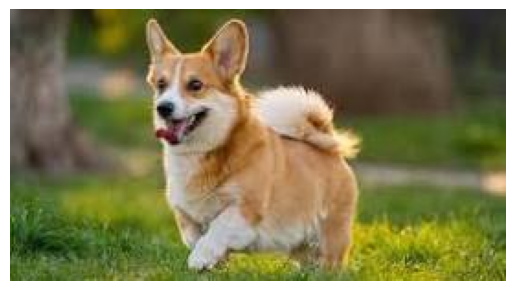

In [ ]:
image_path = list(uploaded.keys())[0]

# Open Image
image = Image.open(image_path)

# Display Image
plt.imshow(image)
plt.axis("off")
plt.show()

In [ ]:
image = image.convert("RGB")

In [ ]:
pixel_values = feature_extractor(
    images=[image],
    return_tensors="pt"
).pixel_values

pixel_values = pixel_values.to(device)

In [ ]:
output_ids = model.generate(
    pixel_values,
    max_length=16,
    num_beams=4
)

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.
You may ignore this warning if your `pad_token_id` (50256) is identical to the `bos_token_id` (50256), `eos_token_id` (50256), or the `sep_token_id` (None), and your input is not padded.


In [ ]:
caption = tokenizer.decode(
    output_ids[0],
    skip_special_tokens=True
)


In [ ]:
print("\nGenerated Caption:")
print(caption)


Generated Caption:
a dog that is standing in the grass 
